# Marci's WIP

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

%matplotlib inline
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
import os
print(os.getcwd())

c:\Users\msieb\OneDrive\Documents\1 NAIT\1 - DATA3950 MACHINE LEARNING\Repository\3950-project-1-vector-s-vengeful-vectors


In [5]:
import keras
import os

# Make sure the folder exists
os.makedirs("data", exist_ok=True)

# Force Keras to use project folder
f_path_1 = "data/train.csv.zip"
url_1 = "https://jrssbcrsefilesnait.blob.core.windows.net/3950data1/train.csv.zip"

if not os.path.exists(f_path_1):
    keras.utils.get_file(
        fname="train.csv.zip",
        origin=url_1,
        cache_dir=".",
        cache_subdir="data"
    )

# Force Keras to use project folder
f_path_2 = "data/test.csv.zip"
url_2 = "https://jrssbcrsefilesnait.blob.core.windows.net/3950data1/test.csv.zip"

if not os.path.exists(f_path_2):
    keras.utils.get_file(
        fname="test.csv.zip",
        origin=url_2,
        cache_dir=".",
        cache_subdir="data"
    )

## Project 1 - NLP and Text Classification

For this project you will need to classify some angry comments into their respective category of angry. The process that you'll need to follow is (roughly):
<ol>
<li> Use NLP techniques to process the training data. 
<li> Train model(s) to predict which class(es) each comment is in.
    <ul>
    <li> A comment can belong to any number of classes, including none. 
    </ul>
<li> Generate predictions for each of the comments in the test data. 
<li> Write your test data predicitions to a CSV file, which will be scored. 
</ol>

You can use any models and NLP libraries you'd like. 

## Training Data

Use the training data to train your prediction model(s). Each of the classification output columns (toxic to the end) is a human label for the comment_text, assessing if it falls into that category of "rude". A comment may fall into any number of categories, or none at all. Membership in one output category is <b>independent</b> of membership in any of the other classes (think about this when you plan on how to make these predictions - it may also make it easier to split work amongst a team...). 

## Test Data

## Output Details, Submission Info, and Example Submission

For this project, please output your predictions in a CSV file. The structure of the CSV file should match the structure of the example below. 

The output should contain one row for each row of test data, complete with the columns for ID and each classification.

Into Moodle please submit:
<ul>
<li> Your notebook file(s). I'm not going to run them, just look. 
<li> Your sample submission CSV. This will be evaluated for accuracy against the real labels; only a subset of the predictions will be scored. 
</ul>

It is REALLY, REALLY, REALLY important the the structure of your output matches the specifications. The accuracies will be calculated by a script, and it is expecting a specific format. 

### Sample Evaluator

The file prediction_evaluator.ipynb contains an example scoring function, scoreChecker. This function takes a sumbission and an answer key, loops through, and evaluates the accuracy. You can use this to verify the format of your submission. I'm going to use the same function to evaluate the accuracy of your submission, against the answer key (unless I made some mistake in this counting function).

In [5]:
#Construct dummy data for a sample output. 
#You won't do this part, you have real data
#Your data should have the same structure, so the CSV output is the same
dummy_ids = ["dfasdf234", "asdfgw43r52", "asdgtawe4", "wqtr215432"]
dummy_toxic = [0,0,0,0]
dummy_severe = [0,0,0,0]
dummy_obscene = [0,1,1,0]
dummy_threat = [0,1,0,1]
dummy_insult = [0,0,1,0]
dummy_ident = [0,1,1,0]
columns = ["id", "toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
sample_out = pd.DataFrame( list(zip(dummy_ids, dummy_toxic, dummy_severe, dummy_obscene, dummy_threat, dummy_insult, dummy_ident)),
                    columns=columns)
sample_out.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,dfasdf234,0,0,0,0,0,0
1,asdfgw43r52,0,0,1,1,0,1
2,asdgtawe4,0,0,1,0,1,1
3,wqtr215432,0,0,0,1,0,0


In [6]:
#Write DF to CSV. Please keep the "out.csv" filename. Moodle will auto-preface it with an identifier when I download it. 
#This command should work with your dataframe of predictions. 
sample_out.to_csv('output/out.csv', index=False)  

## Grading

The grading for this is split between accuracy and well written code:
<ul>
<li> 75% - Accuracy. The most accurate will get 100% on this, the others will be scaled down from there. 
<li> 25% - Code quality. Can the code be followed and made sense of - i.e. comments, sections, titles. 
</ul>

##### ***What type of vectorization should we use?***
- CountVectorizer()
- TfidfVectorizer()
- Word2Vec()

##### ***What strategies should we try?***
- Stemming
- Lemming
- Dimensionality reduction
    - SVD
    - Truncated SVD
    - PCA

##### ***How to classify?***
- RandomForestClassifier()

# Get started

In [6]:
# Load data

train_df = pd.read_csv('data/train.csv.zip')
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [4]:
# Load data

test_df = pd.read_csv('data/test.csv.zip')
test_df.sample(5)

,id,comment_text
27293,27294,::I think I disagree on that basic point. I g...
105110,105111,""" \n\n \n I know it hasn't, but the Watchdog ..."
32307,32308,Try this one Consistent Life Ethic
95583,95584,"== Another welcome! ) == \n\n Hi, I just wante..."
140173,140174,"The reconstruction on the first link, which sh..."


In [10]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  int64 
 1   comment_text  153164 non-null  object
dtypes: int64(1), object(1)
memory usage: 2.3+ MB


In [11]:
# Basic cleaning

train_df['comment_text'] = (
    train_df['comment_text']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip())

test_df['comment_text'] = (
    test_df['comment_text']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip())


In [12]:
train_df.sample(3)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
4273,0b680c5414c2c6e6,i've requested a change to wolfpuss - congratu...,1,0,0,0,0,0
121554,8a558c0577c72df7,that's not what i was talking about. i didn't ...,0,0,0,0,0,0
157332,dc2945e5d34b21d4,few things needed to improve the article... th...,0,0,0,0,0,0


In [13]:
test_df.sample(3)

,id,comment_text
122172,122173,==sorry== sorry it was my brother he is a idiot
146264,146265,but i said im sorry '(
62820,62821,== super-carrier? admiral kuznetsov == a recen...


## **Models**

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
from sklearn import metrics
from sklearn.metrics import classification_report

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

In [6]:
# Split X and y

target = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

y = train_df[target]
X = train_df['comment_text']
X_train, X_test, y_train, y_test = train_test_split(X, y)

### *Model 1: Basic*

In [45]:
# Build pipeline

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('clf', OneVsRestClassifier(LinearSVC()))
    ])

pipe.fit(X_train, y_train)

# Make predictions
y_pred = pipe.predict(X_test)

In [21]:
# Evaluate model

print(classification_report(y_test, y_pred, target_names=target))

               precision    recall  f1-score   support

        toxic       0.89      0.69      0.78      3837
 severe_toxic       0.54      0.29      0.38       406
      obscene       0.89      0.71      0.79      2146
       threat       0.76      0.24      0.36       136
       insult       0.80      0.62      0.70      1979
identity_hate       0.66      0.25      0.37       362

    micro avg       0.85      0.64      0.73      8866
    macro avg       0.76      0.47      0.56      8866
 weighted avg       0.84      0.64      0.72      8866
  samples avg       0.06      0.06      0.06      8866



c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [50]:
multilabel_confusion_matrix(y_test, y_pred)

array([[[35813,   301],
        [ 1184,  2595]],

       [[39393,   102],
        [  286,   112]],

       [[37586,   192],
        [  608,  1507]],

       [[39768,    17],
        [   77,    31]],

       [[37630,   302],
        [  737,  1224]],

       [[39516,    56],
        [  226,    95]]])

#### *Model 1 Performance:*
- Classification report:
    - * Total data points only 8,866.  Really thought there'd be more.  Pretty sure that can't be correct.
    - toxic:
        - Lots of data points so metrics can be relied on
        - Few false positives, some false negatives, f1-score is not bad but could be better
        - Model did a decent job of classifying
    - severe_toxic:
        - Few data points
        - Scores are poor
        - Model did a poor job of classifying
    - obscene:
        - Lots of data points so metrics can be relied on
        - Few false positives, some false negatives, f1-score is not bad but could be better
        - Model did a decent job of classifying
    - threat:
        - Very few data points, metrics not reliable
        - Not many false positives, a lot of false negatives, but again - not reliable
        - Model did a poor job of classifying
    - insult:
        - Fair number of data points
        - OK f1-score, definetly could be better
    - identity_hate:
        - Few data points
        - False positive score not horrible, but false neg is bad - not reliable
    - micro/macro average ok-ish
    - weighted averages ok but I would like them to be higher and more balanced
    - samples avg is super low
- Multi-class label matrix
    - True negatives really hight
    - True positives really low
    - False negatives kind of high in some areas
- ***Overall, I don't think this model was terrible, but it also wasn't great at predicting classes***

#### Create some helper functions

In [8]:
import nltk

for package in ['stopwords','punkt','wordnet']:
    nltk.download(package)
    
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english')) 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\msieb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\msieb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\msieb\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [9]:
# Custom stop word tokenizer

class swTokenizer(object):
    def __init__(self, stop_words):
        self.stop_words = stop_words
    def __call__(self, doc):
        tokens = word_tokenize(doc)
        filtered_tok = []
        for tok in tokens:
            if tok not in stop_words:
                filtered_tok.append(tok)
        return filtered_tok

In [10]:
# Custom stem word tokenizer

class stemTokenizer(object):
    def __init__(self, stop_words):
        self.stop_words = stop_words
        from nltk.stem import SnowballStemmer
        self.stemmer = SnowballStemmer(language='english')
    def __call__(self, doc):
        tokens = word_tokenize(doc)
        filtered_tok = []
        for tok in tokens:
            if tok not in stop_words:
                filtered_tok.append(self.stemmer.stem(tok))
        return filtered_tok

In [11]:
# Custom lemmatization tokenizer

class lemmaTokenizer(object):
    def __init__(self, stop_words):
        self.stop_words = stop_words
        from nltk.stem import WordNetLemmatizer
        self.lemmatizer = WordNetLemmatizer()
    def __call__(self, doc):
        tokens = word_tokenize(doc)
        filtered_tok = []
        for tok in tokens:
            if tok not in stop_words:
                filtered_tok.append(self.lemmatizer.lemmatize(tok))
        return filtered_tok

In [12]:
# Integrate rare tokenizers

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))        # Load a list of common stop words and convert to a set (cuz it's faster, I think)

lemma_tok = lemmaTokenizer(stop_words)              # Create an instance custom lemmaTokenizer class

In [13]:
# Custom function to clean text

def clean_toxic_text(text):

    # Lowercase everything
    text = text.lower()

# Normalize obfuscated characters (cleans up altered offensive words ex. 'st00pid')
    substitutions = {
        '@': 'a',
        '1': 'i',
        '!': 'i',
        '3': 'e',
        '4': 'a',
        '0': 'o',
        '$': 's',
        '7': 't'
    }
    for k, v in substitutions.items():
        text = text.replace(k, v)                                                           # Replace text found in keys with cooresponding value

    # Remove repeated characters (ex. 'stuuuuupid' = 'stuupid')
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)                                              # Find characters repeated 3 or more times and reduce to 2

    # Remove spacing tricks ('i d i o t' = 'idiot')
    text = re.sub(r'(\b\w\s+){2,}\w\b', lambda m: m.group(0).replace(' ', ''), text)        # Detects letter, space, letter, space patterns and collapses them

    # Remove non-alphanumeric (except punctuation)
    text = re.sub(r"[^a-z0-9!?.,']", ' ', text)                                             # Removes emojis, symbols, weird punctuation (keeps normal stuff like !?,.')

    # Fix whitespace
    text = re.sub(r'\s+', ' ', text).strip()                                                # Removes extra spaces like double spaces, tabs, newlines, and trims ends

    return text

In [14]:
# I don't really get this, but apparently I need it...

from sklearn.base import BaseEstimator, TransformerMixin

class TextCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, clean_func):
        self.clean_func = clean_func

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.apply(self.clean_func)

In [15]:
# Custom function to oversample rare labels

from sklearn.utils import resample

def oversample_rare_labels(df, rare_labels, factor=3):
    rare = df[df[rare_labels].sum(axis=1) > 0]                      # Select rare rows - count rare labels per row and select rows with count greater than 0
    common = df[df[rare_labels].sum(axis=1) == 0]                   # Select common rows - count rare labels per row and select rows with count equal to 0

    rare_oversampled = resample(
        rare,
        replace=True,                                               # Allow sampling more than once
        n_samples=len(rare) * factor,                               # Increase rows by chosen factor 
        random_state=42
    )

    return pd.concat([common, rare_oversampled], axis=0).sample(frac=1, random_state=42)       # frac=1 means use all of the data in the sample (basically just shuffling the data)

### *Model 2:*
- extra cleaning
- tokenization
- oversampling of rare data
- set a few hyperparameters

In [76]:
# Perform oversampling

# Combine the training data
train_data = pd.concat([X_train, y_train], axis=1)

# Call the function
train_df_os = oversample_rare_labels(train_data, rare_labels=['threat','identity_hate','severe_toxic'])

# Resplit train_data
X_train_os = train_df_os['comment_text']
y_train_os = train_df_os[target]

In [82]:
# Build the pipeline

pipe = Pipeline([
    ('clean', TextCleaner(clean_toxic_text)),                               # Use custom clean function
    ('tfidf', TfidfVectorizer(
        tokenizer=lemma_tok,                                                # Use custom tokenizer (lemmatization)
        ngram_range=(1,2),                                                  # look for 1 and 2 word tokens
        min_df=3,                                                           # Ignore terms that appear less than 3 times
        max_features=100000                                                 # Vocab dictionary capped at this number
    )),
    ('clf', OneVsRestClassifier(LinearSVC()))    
])


In [83]:
# Fit pipeline to training data
pipe.fit(X_train_os, y_train_os)

c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,steps,"[('clean', ...), ('tfidf', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,clean_func,<function cle...002433956CF70>
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None


In [84]:
# Make predictions
y_pred = pipe.predict(X_test)

In [85]:
# Evaluate model

print(classification_report(y_test, y_pred, target_names=target))

               precision    recall  f1-score   support

        toxic       0.87      0.68      0.76      3779
 severe_toxic       0.44      0.30      0.36       398
      obscene       0.87      0.70      0.78      2115
       threat       0.57      0.28      0.37       108
       insult       0.78      0.59      0.67      1961
identity_hate       0.59      0.34      0.43       321

    micro avg       0.82      0.63      0.71      8682
    macro avg       0.69      0.48      0.56      8682
 weighted avg       0.82      0.63      0.71      8682
  samples avg       0.06      0.06      0.06      8682



c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


- Model 1 results
    - 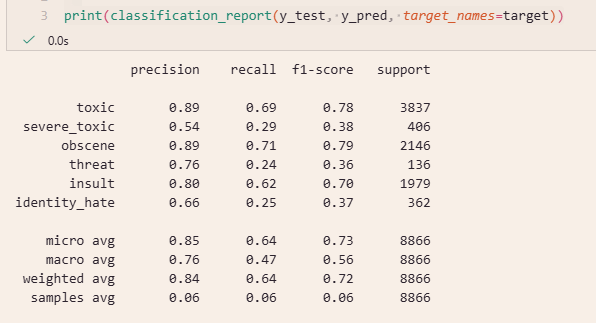

In [86]:
# Evaluate model

multilabel_confusion_matrix(y_test, y_pred)

array([[[35732,   382],
        [ 1205,  2574]],

       [[39343,   152],
        [  278,   120]],

       [[37561,   217],
        [  636,  1479]],

       [[39762,    23],
        [   78,    30]],

       [[37612,   320],
        [  808,  1153]],

       [[39496,    76],
        [  213,   108]]])

#### *Model 2 Performance:*
- Classification report:
    - *Well that's annoying. It doesn't really look any better than the basic model...*
        - Data points decreased, but I think 8600 is actually a reasonable number
        - False positives increased slightly across the board
        - False negatives stayed more or less the same
        - f1-score jumped around a bit but increased just a tiny bit overall
- ***The oversampling didn't seem to help the recall scores***
- ***Tuning and extra cleaning might have made a small difference in precision scores***

### *Model: 3*
- keep the extra cleaning
- keep the tokenizer
- keep oversampling
- try a different classifier with grid search

In [15]:
# Perform oversampling

# Combine the training data
train_data = pd.concat([X_train, y_train], axis=1)

# Call the function
train_df_os = oversample_rare_labels(train_data, rare_labels=['threat','identity_hate','severe_toxic'])

# Resplit train_data
X_train_os = train_df_os['comment_text']
y_train_os = train_df_os[target]

In [16]:
# Build the pipeline

from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ('clean', TextCleaner(clean_toxic_text)),                               # Use custom clean function
    ('tfidf', TfidfVectorizer(
        tokenizer=lemma_tok,                                                # Use custom tokenizer (lemmatization)
        ngram_range=(1,2),                                                  # look for 1 and 2 word tokens
        min_df=3,                                                           # Ignore terms that appear less than 3 times
        max_features=100000                                                 # Vocab dictionary capped at this number
    )),
    ('clf', RandomForestClassifier())    
])

In [1]:
# Define grid

param_grid = {
    'tfidf__min_df': [3, 5, 10],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__n_estimators': [200, 500],
    'clf__max_depth': [None, 5, 8]
}

In [ ]:


grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1_micro',  
    cv=3,
    n_jobs=-1,
    verbose=2
)

NameError: name 'pipe' is not defined

In [ ]:
# Fit pipeline to training data
grid.fit(X_train_os, y_train_os)

c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
# Make predictions
y_pred = pipe.predict(X_test)

In [ ]:
# Evaluate model

print(classification_report(y_test, y_pred, target_names=target))

In [ ]:
# Evaluate model

multilabel_confusion_matrix(y_test, y_pred)

#### *Model 3 Performance:*
- Classification report:
    - *Well that's annoying. It doesn't really look any better than the basic model...*
        - Data points decreased, but I think 8600 is actually a reasonable number
        - False positives increased slightly across the board
        - False negatives stayed more or less the same
        - f1-score jumped around a bit but increased just a tiny bit overall
- ***The oversampling didn't seem to help the recall scores***
- ***Tuning and extra cleaning might have made a small difference in precision scores***

## **Final predictions on test_df**

In [ ]:
# Retrain model with 100% of data

pipe.fit(train_df['comment_text'], train_df[target])

c:\Users\msieb\anaconda3\envs\ml\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [23]:
# Make predictions

y_pred = pipe.predict(test_df['comment_text'])

In [24]:
# Convert array to df

pred_df = pd.DataFrame(y_pred, columns=target)

In [25]:
# Attach 'id' column (reset index)

final_df = pd.concat([
    test_df['id'].reset_index(drop=True), 
    pred_df.reset_index(drop=True)], 
    axis=1)

In [26]:
final_df.sample(5)

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
136767,136768,1,0,0,0,0,0
78468,78469,1,0,1,0,0,0
10894,10895,1,0,0,0,0,0
95669,95670,0,0,0,0,0,0
115274,115275,1,0,1,0,1,0


In [27]:
# Make sure everything lines up

len(final_df) == len(test_df)

True

In [28]:
# Check for nulls

test_df['comment_text'].isna().sum()

np.int64(0)

In [29]:
# Export predictions to CSV

final_df.to_csv('output/out.csv', index=False)  